<a href="https://colab.research.google.com/github/sarthakpol7117-droid/neon-blaster/blob/main/codomax_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 100)
scores = 5 + hours_studied * 8 + np.random.normal(0, 5, 100)   # some noise added
scores = np.clip(scores, 0, 100)

student_df = pd.DataFrame({'HoursStudied': hours_studied, 'Score': scores})
student_df.head()

,HoursStudied,Score
0,4.370861,40.402124
1,9.556429,79.956393
2,7.587945,66.162368
3,6.387926,46.165566
4,2.404168,23.134983


In [ ]:
X = student_df[['HoursStudied']]   # features must be 2D
y = student_df['Score']             # target is 1D

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 80, Test size: 20


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Slope (coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
# Interpretation: each extra hour studied predicts ~this many more points

Slope (coefficient): 7.78
Intercept: 5.94


In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")   # average error in points
print(f"MSE: {mse:.2f}")   # penalizes big errors more
print(f"R²: {r2:.2f}")     # how much variance the model explains (closer to 1 = better)

MAE: 2.96
MSE: 16.34
R²: 0.97


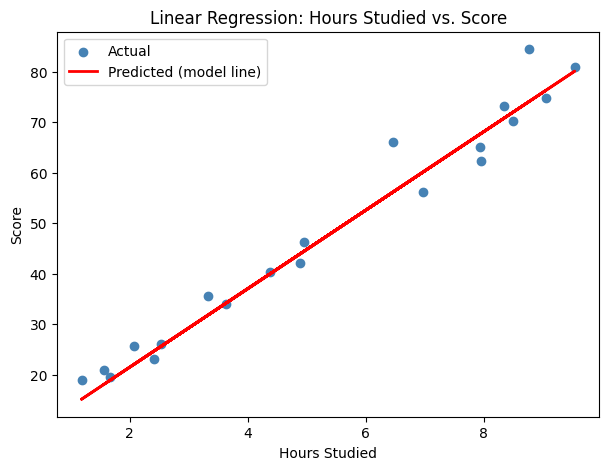

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color='steelblue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted (model line)')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Linear Regression: Hours Studied vs. Score')
plt.legend()
plt.show()

In [ ]:
np.random.seed(1)
n = 200
size_sqft = np.random.uniform(500, 3500, n)
bedrooms = np.random.randint(1, 6, n)
age_years = np.random.uniform(0, 40, n)

price = (size_sqft * 150) + (bedrooms * 10000) - (age_years * 800) + np.random.normal(0, 15000, n)

house_df = pd.DataFrame({
    'SizeSqFt': size_sqft,
    'Bedrooms': bedrooms,
    'AgeYears': age_years,
    'Price': price
})
house_df.head()

,SizeSqFt,Bedrooms,AgeYears,Price
0,1751.066014,5,13.811898,302326.180144
1,2660.973480,2,31.863547,363957.049084
2,500.343124,5,17.845849,127554.012586
3,1406.997718,2,31.309977,216799.573154
4,940.267672,3,39.618871,160007.704203


In [ ]:
house_df.corr()['Price'].sort_values(ascending=False)

,Price
Price,1.000000
SizeSqFt,0.985277
Bedrooms,0.217174
AgeYears,-0.175832


In [ ]:
X = house_df[['SizeSqFt', 'Bedrooms', 'AgeYears']]
y = house_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
house_model = LinearRegression()
house_model.fit(X_train, y_train)

y_pred = house_model.predict(X_test)

print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

# Which feature matters most?
for feature, coef in zip(X.columns, house_model.coef_):
    print(f"{feature}: {coef:.2f}")

MAE: $10,697
R²: 0.99
SizeSqFt: 150.09
Bedrooms: 12081.75
AgeYears: -850.81


In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species_name'] = iris_df['species'].map(dict(enumerate(iris.target_names)))
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


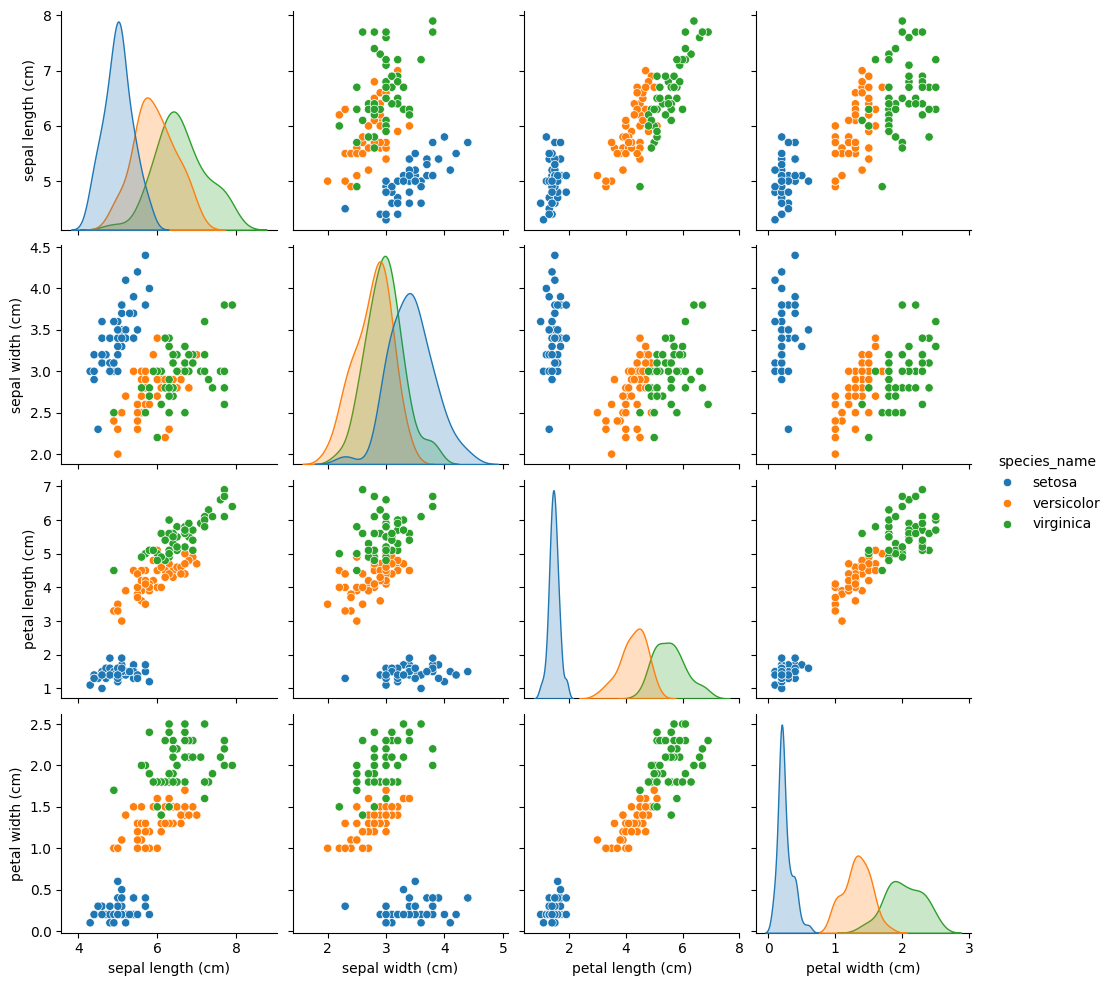

In [ ]:
iris_df['species_name'].value_counts()   # 50 samples per species — perfectly balanced

import seaborn as sns
sns.pairplot(iris_df, hue='species_name', vars=iris.feature_names)
plt.show()

In [ ]:
X = iris_df[iris.feature_names]
y = iris_df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nFull Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 96.67%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Full Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)
tree_pred = tree_clf.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, tree_pred):.2%}")

Logistic Regression Accuracy: 96.67%
Decision Tree Accuracy: 96.67%


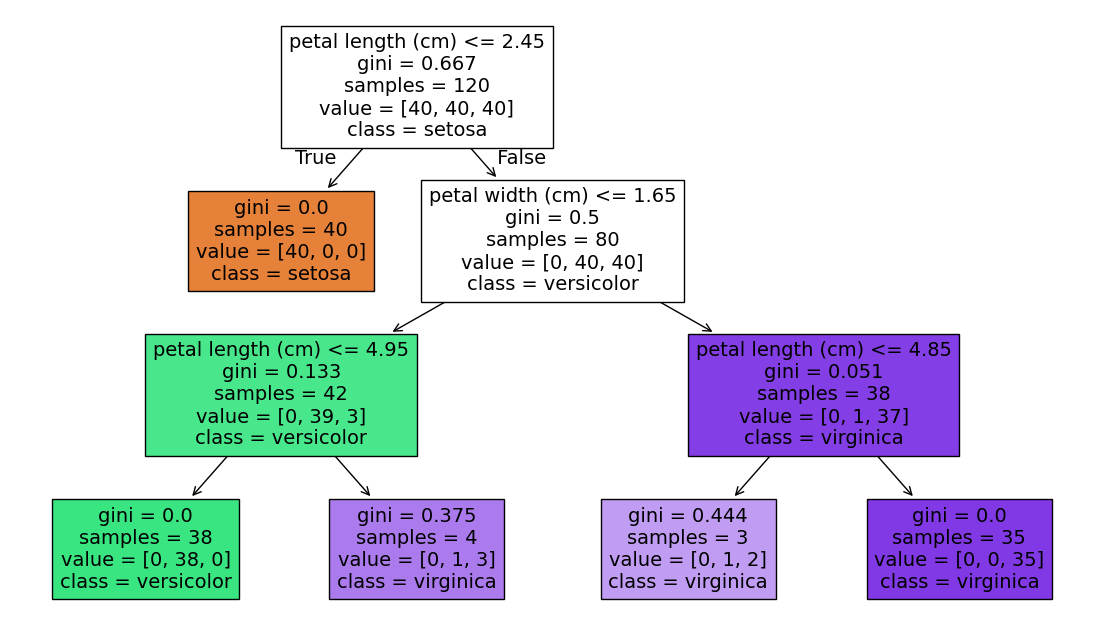

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(tree_clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()